# GREAC — k × window × threshold sweep

Reads the `parameter_sweep_<organism>.csv` written by `fit-parameters` in `GREAC/output-sweep-<organism>/`
(one row per repetition × combination) and aggregates mean ± standard deviation over the repetitions.
Each repetition is an independent train/test split, which is where the deviation comes from.

**Parameters** (next cell, tagged `parameters`):

- `ORGANISM` — suffix of the `output-sweep-*` directory (the available list is printed on load)
- `MIN_COVERAGE` — minimum fraction of the test set a combination must classify to enter the ranking
- `TOP_N` — how many combinations to show in the ranking and in the per-repetition distribution
- `DECIMALS` — decimal places of the metrics in tables and prints; window, threshold and `summary.csv` keep full precision
- `WINDOWS_INCLUDE` / `WINDOWS_EXCLUDE` — restrict the windows considered (empty = all). The filter is applied
  before any aggregation, so ranking, ties, heatmaps, timings and `summary.csv` all use only the chosen windows


**Two pitfalls in this data:**
- **Coverage.** GREAC drops test sequences with no k-mer in the selected regions and computes F1 only over the
  remaining ones. A combination can reach a high F1 while classifying a small fraction of the test set. Coverage is
  `n_test` divided by the largest `n_test` of the same repetition (the same split). It is a lower bound of the real
  test set: if no combination classifies everything, coverage is overestimated.
- **Holes in the grid.** The window in bases is `ceil(shortest sequence × window)`, and k larger than the window
  does not run. Those combinations have no row in the CSV and show up in the heatmaps as *not run*, not as zero.

In [ ]:
ORGANISM = "sars"
MIN_COVERAGE = 0.95
TOP_N = 10
DECIMALS = 4          # decimal places in tables and prints (window/threshold are not rounded)
WINDOWS_INCLUDE = []   # [] = all; e.g. [0.0025, 0.003] keeps only these
WINDOWS_EXCLUDE = []   # e.g. [0.0015] drops this window

In [62]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SWEEP_ROOT = os.path.join("..", "GREAC")
SWEEPS = {
    os.path.basename(d).removeprefix("output-sweep-"): d
    for d in sorted(glob.glob(os.path.join(SWEEP_ROOT, "output-sweep-*")))
}
if ORGANISM not in SWEEPS:
    raise ValueError(f"ORGANISM {ORGANISM!r} has no sweep in {SWEEP_ROOT}; available: {sorted(SWEEPS)}")

# Shards of the current sweep: the base file plus one .part-<run-id> per parallel job.
# Archived ones (parameter_sweep_<org>_<timestamp>.csv, or archived/) are earlier
# experiments and are left out of the mean.
CSV_PATHS = [p for p in (
    [os.path.join(SWEEPS[ORGANISM], f"parameter_sweep_{ORGANISM}.csv")]
    + sorted(glob.glob(os.path.join(SWEEPS[ORGANISM], f"parameter_sweep_{ORGANISM}.part-*.csv")))
) if os.path.exists(p)]
if not CSV_PATHS:
    raise FileNotFoundError(f"no parameter_sweep_{ORGANISM}*.csv in {SWEEPS[ORGANISM]}")

FIG_DIR = os.path.join("figs", "greac", ORGANISM)
os.makedirs(FIG_DIR, exist_ok=True)
TITLE = f"GREAC · {ORGANISM}"
print("available sweeps:", sorted(SWEEPS))

available sweeps: ['denv', 'hbv', 'hiv', 'mkpx', 'sars']


## Style

In [63]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # same fixed order as kmer_sweep_runlogs.ipynb
ACCENT = SERIES[0]
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#a3a29d", "#e3e2dd", "#ffffff"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "center",
    "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10, "figure.dpi": 120,
})

# Figures that go to the paper are shrunk to half (sweep curves) or the full text width (ROC):
# with the figure sizes of those cells, these fonts come out at ~7 pt in the PDF
PAPER_RC = {"font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
            "xtick.labelsize": 12, "ytick.labelsize": 12,
            "legend.fontsize": 12, "legend.title_fontsize": 12}

# The window is ordinal: a single hue from light to dark, not categorical colors.
# Starts at 0.45 of the ramp so the smallest window does not vanish into the background.
SEQ = LinearSegmentedColormap.from_list("seq", ["#e4eefb", ACCENT, "#0d2f5c"])


def window_colors(windows):
    windows = sorted(windows)
    if len(windows) == 1:
        return {windows[0]: ACCENT}
    return {w: SEQ(0.45 + 0.55 * i / (len(windows) - 1)) for i, w in enumerate(windows)}


def mean_band(ax, x, mean, std, color, label=None):
    """Mean line with a ±1 standard deviation band (no band when n=1)."""
    std = std.fillna(0)
    ax.fill_between(x, (mean - std).clip(lower=0), (mean + std).clip(upper=1),
                    color=color, alpha=0.15, linewidth=0)
    ax.plot(x, mean, marker="o", color=color, label=label,
            markeredgecolor=SURFACE, markeredgewidth=2)


def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, os.path.splitext(name)[0] + ".pdf"), bbox_inches="tight")  # vector, for the paper

## Loading the data

One row per (repetition, window, threshold, k), merging the shards: parallel jobs each write their own
`parameter_sweep_<org>.part-<run-id>.csv`. The last repetition of each job may be incomplete if the sweep is still
running or was cut short; it enters the mean with whatever it has, and the `n` of each combination shows how many
repetitions back it.

In [64]:
raw = pd.concat([pd.read_csv(p).assign(shard=os.path.basename(p)) for p in CSV_PATHS],
                ignore_index=True)
raw = raw.drop_duplicates(subset=["rep", "window", "threshold", "kmer"], keep="last")

# Window and threshold come from Float32/Float16 in Julia: round them so grouping does
# not treat "0.0025" and "0.0025000002" as different windows
raw["window"] = raw["window"].round(6)
raw["threshold"] = raw["threshold"].round(3)
raw["train_time"] = raw["extract_time"] + raw["fit_time"]
raw["coverage"] = raw["n_test"] / raw.groupby("rep")["n_test"].transform("max")

# Window filter before any aggregation: everything below (ranking, heatmaps,
# timings, summary) applies only to the chosen windows
ALL_WINDOWS = sorted(raw.window.unique().tolist())
if WINDOWS_INCLUDE:
    missing = [w for w in WINDOWS_INCLUDE if w not in ALL_WINDOWS]
    if missing:
        raise ValueError(f"windows without data: {missing}; available: {ALL_WINDOWS}")
    raw = raw[raw.window.isin(WINDOWS_INCLUDE)]
if WINDOWS_EXCLUDE:
    raw = raw[~raw.window.isin(WINDOWS_EXCLUDE)]
if raw.empty:
    raise ValueError(f"no rows left after the window filter (available: {ALL_WINDOWS})")
if WINDOWS_INCLUDE or WINDOWS_EXCLUDE:
    print(f"windows considered: {sorted(raw.window.unique().tolist())} of {ALL_WINDOWS}")

KS = sorted(raw.kmer.unique().tolist())
WINDOWS = sorted(raw.window.unique().tolist())
THRESHOLDS = sorted(raw.threshold.unique().tolist())
REPS = sorted(raw.rep.unique().tolist())

rows_per_rep = raw.groupby("rep").size()
grid = len(KS) * len(WINDOWS) * len(THRESHOLDS)
print(f"{TITLE}: {len(raw)} rows, {len(REPS)} repetitions, {len(CSV_PATHS)} shard(s)")
for p in CSV_PATHS:
    print("  ", os.path.basename(p))
print(f"grid: k={KS} × window={WINDOWS} × threshold={THRESHOLDS} = {grid} combinations")
print(f"rows per repetition: median {int(rows_per_rep.median())}, min {rows_per_rep.min()} "
      f"(rep {rows_per_rep.idxmin()}), max {rows_per_rep.max()}")

pd.crosstab(raw.window, raw.kmer, values=raw.rep, aggfunc="nunique").fillna(0).astype(int) \
  .rename_axis(index="window \\ k", columns=None)

GREAC · mkpx: 1393 rows, 16 repetitions, 7 shard(s)
   parameter_sweep_mkpx.part-184383-undefined.csv
   parameter_sweep_mkpx.part-184386-undefined.csv
   parameter_sweep_mkpx.part-184392-undefined.csv
   parameter_sweep_mkpx.part-184393-undefined.csv
   parameter_sweep_mkpx.part-184438-undefined.csv
   parameter_sweep_mkpx.part-184440-undefined.csv
   parameter_sweep_mkpx.part-184448-undefined.csv
grid: k=[5, 6, 7, 8, 9, 10] × window=[5e-05, 6e-05, 7e-05, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.001, 0.0015, 0.002] × threshold=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8] = 462 combinations
rows per repetition: median 94, min 6 (rep 12), max 210


,5,6,7,8,9,10
window \ k,,,,,,
0.00005,1,1,1,1,1,1
0.00006,1,1,1,1,1,1
0.00007,1,1,1,1,1,1
0.00010,2,2,2,2,2,2
0.00020,2,2,2,2,2,2
0.00030,1,1,1,1,1,1
0.00040,1,1,1,1,1,1
0.00050,6,6,6,6,6,6
0.00100,13,13,13,13,12,12


The table above counts the repetitions per window × k. A zero is a combination that never ran
(k larger than the window in bases).

In [65]:
KEYS = ["window", "threshold", "kmer"]


def rounded(df):
    """Round the metrics to DECIMALS; the keys stay intact (0.0025 would become 0.0)."""
    return df.round({c: DECIMALS for c in df.columns if c not in KEYS})

METRICS = ["f1_score", "precision", "recall", "coverage",
           "kmerset", "final_len", "windows",
           "extract_time", "fit_time", "train_time", "classify_time"]

agg = raw.groupby(KEYS).agg(
    n=("rep", "nunique"),
    **{f"{m}_mean": (m, "mean") for m in METRICS},
    **{f"{m}_std": (m, "std") for m in METRICS},
    coverage_min=("coverage", "min"),
).reset_index()

agg["eligible"] = agg["coverage_mean"] >= MIN_COVERAGE
ranking = agg[agg.eligible].sort_values("f1_score_mean", ascending=False).reset_index(drop=True)
ranking.index += 1

excluded = (~agg.eligible).sum()
print(f"{len(agg)} combinations; {excluded} left out of the ranking for coverage < {MIN_COVERAGE:.0%}")

SHOW = ["window", "threshold", "kmer", "n", "f1_score_mean", "f1_score_std",
        "precision_mean", "recall_mean", "coverage_mean", "kmerset_mean", "final_len_mean", "windows_mean",
        "train_time_mean", "classify_time_mean"]
rounded(ranking[SHOW].head(TOP_N))

442 combinations; 0 left out of the ranking for coverage < 95%


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,kmerset_mean,final_len_mean,windows_mean,train_time_mean,classify_time_mean
1,0.002,0.80,10,2,1.0,0.0,1.0,1.0,1.0,115494.5,197500.5,1.0,374.0184,125.2143
2,0.002,0.80,9,2,1.0,0.0,1.0,1.0,1.0,75385.5,197500.5,1.0,239.0897,124.3713
3,0.002,0.80,8,2,1.0,0.0,1.0,1.0,1.0,32189.0,197491.0,1.0,121.2314,123.5761
4,0.002,0.75,10,2,1.0,0.0,1.0,1.0,1.0,115494.5,197502.5,1.0,379.9741,111.5158
5,0.002,0.60,10,2,1.0,0.0,1.0,1.0,1.0,115494.5,197516.0,1.0,370.0241,108.8654
6,0.002,0.60,9,2,1.0,0.0,1.0,1.0,1.0,75385.5,197512.5,1.0,233.2010,111.4485
7,0.002,0.60,8,2,1.0,0.0,1.0,1.0,1.0,32189.0,197505.0,1.0,112.1600,110.7924
8,0.002,0.60,7,2,1.0,0.0,1.0,1.0,1.0,9048.5,197504.0,1.0,63.5779,120.9998
9,0.002,0.60,6,2,1.0,0.0,1.0,1.0,1.0,2192.5,197504.0,1.0,54.4485,116.1079
10,0.002,0.55,10,2,1.0,0.0,1.0,1.0,1.0,115494.5,197534.5,1.0,371.6148,114.2744


In [66]:
agg

,window,threshold,kmer,n,f1_score_mean,precision_mean,recall_mean,coverage_mean,kmerset_mean,final_len_mean,...,coverage_std,kmerset_std,final_len_std,windows_std,extract_time_std,fit_time_std,train_time_std,classify_time_std,coverage_min,eligible
0,0.00005,0.5,5,1,0.33340,0.25000,0.50000,1.0,517.0,166220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True
1,0.00005,0.5,6,1,0.33340,0.25000,0.50000,1.0,2187.0,145129.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True
2,0.00005,0.5,7,1,0.96950,0.97120,0.96950,1.0,8724.0,142498.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True
3,0.00005,0.5,8,1,0.99850,0.99850,0.99850,1.0,29199.0,188638.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True
4,0.00005,0.5,9,1,1.00000,1.00000,1.00000,1.0,63901.0,195200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,0.00200,0.8,6,2,0.99925,0.99925,0.99925,1.0,2192.5,197489.0,...,0.0,0.707107,0.00000,0.0,0.076566,3.517389,3.440823,3.098863,1.0,True
438,0.00200,0.8,7,2,0.99925,0.99925,0.99925,1.0,9048.5,197491.0,...,0.0,95.459415,0.00000,0.0,0.707485,5.522139,4.814653,10.331807,1.0,True
439,0.00200,0.8,8,2,1.00000,1.00000,1.00000,1.0,32189.0,197491.0,...,0.0,732.562625,0.00000,0.0,0.117362,14.556647,14.439285,1.646423,1.0,True
440,0.00200,0.8,9,2,1.00000,1.00000,1.00000,1.0,75385.5,197500.5,...,0.0,2355.372688,2.12132,0.0,6.303052,20.186858,26.489910,1.339277,1.0,True


## 1. Ranking — what is actually a tie

F1 differences smaller than the deviation across repetitions do not tell combinations apart. The table lists
the combinations whose mean lies within 1 standard deviation of the best one. Within that tie the choice favours
the model that needs the least information to classify: largest number of `windows` (regions) first, then the
smallest `final_len` (summed bases of the selected regions). The first row of the table is the chosen
combination: an F1 statistically equal to the best one, with the smallest model.

In [42]:
raw

,timestamp,rep,window,threshold,kmer,metric,f1_score,precision,recall,windows,kmerset,final_len,extract_time,fit_time,classify_time,n_test,shard,train_time,coverage
0,2026-09-18T17:29:47.744,1,0.0015,0.50,5,manhattan,0.9485,0.9457,0.9521,3,411,9583,1.523155,6.882272,3.194744,295,parameter_sweep_hiv.csv,8.405426,1.000000
1,2026-09-18T17:29:53.572,1,0.0015,0.50,6,manhattan,0.9670,0.9640,0.9722,1,1246,9645,0.688834,2.563242,1.107623,295,parameter_sweep_hiv.csv,3.252076,1.000000
2,2026-09-18T17:29:57.974,1,0.0015,0.50,7,manhattan,0.9924,0.9953,0.9899,10,1473,9339,0.536735,2.438092,1.425746,295,parameter_sweep_hiv.csv,2.974826,1.000000
3,2026-09-18T17:30:00.922,1,0.0015,0.50,8,manhattan,0.9747,0.9762,0.9737,47,810,7194,0.327872,1.802827,0.814466,295,parameter_sweep_hiv.csv,2.130698,1.000000
4,2026-09-18T17:30:01.837,1,0.0015,0.50,9,manhattan,0.4556,0.5074,0.4689,18,308,462,0.481718,0.200802,0.230159,295,parameter_sweep_hiv.csv,0.682520,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12855,2026-09-23T10:57:01.887,119,0.0020,0.70,9,manhattan,0.2996,0.5197,0.3492,6,307,202,0.316780,0.128582,0.170946,295,parameter_sweep_hiv.csv,0.445362,1.000000
12856,2026-09-23T10:57:02.81,119,0.0020,0.70,10,manhattan,0.1986,0.4037,0.2654,1,142,20,0.787918,0.100229,0.033889,112,parameter_sweep_hiv.csv,0.888146,0.379661
12857,2026-09-23T10:57:05.076,119,0.0020,0.75,5,manhattan,0.9548,0.9556,0.9584,1,412,8979,0.331238,1.181122,0.751928,295,parameter_sweep_hiv.csv,1.512360,1.000000
12858,2026-09-23T10:57:07.89,119,0.0020,0.75,6,manhattan,0.9863,0.9857,0.9873,2,1259,9085,0.411440,1.614228,0.784910,295,parameter_sweep_hiv.csv,2.025669,1.000000


In [43]:
best = ranking.iloc[0]
tie_floor = best.f1_score_mean - (0 if np.isnan(best.f1_score_std) else best.f1_score_std)
ties = ranking[ranking.f1_score_mean >= tie_floor].sort_values(
    ["windows_mean", "final_len_mean" ], ascending=[False, True])
choice = ties.iloc[0]

print(f"best: window={best.window}, threshold={best.threshold}, k={int(best.kmer)} "
      f"→ F1 {best.f1_score_mean:.{DECIMALS}f} ± {best.f1_score_std:.{DECIMALS}f} (n={int(best.n)})")
print(f"choice: window={choice.window}, threshold={choice.threshold}, k={int(choice.kmer)} "
      f"→ F1 {choice.f1_score_mean:.{DECIMALS}f} ± {choice.f1_score_std:.{DECIMALS}f}, "
      f"final_len {choice.final_len_mean:.0f}, windows {choice.windows_mean:.1f} (n={int(choice.n)})")
print(f"{len(ties)} combinations with mean F1 ≥ {tie_floor:.{DECIMALS}f}, sorted by windows ↓ → final_len ↑:")
rounded(ties[SHOW])

best: window=0.003, threshold=0.65, k=8 → F1 0.9936 ± 0.0052 (n=52)
choice: window=0.0025, threshold=0.7, k=8 → F1 0.9892 ± 0.0077, final_len 7854, windows 18.7 (n=52)
33 combinations with mean F1 ≥ 0.9884, sorted by windows ↓ → final_len ↑:


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,kmerset_mean,final_len_mean,windows_mean,train_time_mean,classify_time_mean
24,0.0025,0.70,8,52,0.9892,0.0077,0.9875,0.9915,1.0,775.5000,7854.4038,18.6538,3.0977,1.2438
7,0.0020,0.55,8,119,0.9910,0.0066,0.9897,0.9926,1.0,773.4622,8212.0924,14.7311,2.4327,0.9979
8,0.0025,0.65,8,52,0.9909,0.0067,0.9894,0.9928,1.0,775.5000,8262.8654,10.1731,3.1199,1.3255
13,0.0030,0.75,8,52,0.9898,0.0075,0.9880,0.9922,1.0,775.5000,8169.2500,9.6538,3.2357,1.3876
12,0.0020,0.50,8,119,0.9900,0.0075,0.9888,0.9917,1.0,773.4622,8498.1933,8.5798,2.4214,1.0340
5,0.0025,0.60,8,52,0.9916,0.0058,0.9901,0.9934,1.0,775.5000,8528.3077,6.3846,2.9844,1.3208
4,0.0030,0.70,8,52,0.9917,0.0064,0.9901,0.9934,1.0,775.5000,8435.2115,5.3846,3.2689,1.4581
9,0.0025,0.55,8,52,0.9909,0.0063,0.9890,0.9931,1.0,775.5000,8701.7500,5.1538,2.8647,1.3526
1,0.0030,0.65,8,52,0.9936,0.0052,0.9925,0.9950,1.0,775.5000,8630.9423,4.3462,3.0224,1.4393
25,0.0025,0.50,8,53,0.9892,0.0092,0.9871,0.9918,1.0,775.5660,8851.1132,4.2075,2.8552,1.3430


## 2. Best F1 per k

One bar per window at each k, with the best threshold for that window and k (only combinations eligible by
coverage). The error bar is ±1 standard deviation across repetitions.

The axis starts at zero, as bars require: that is what immediately shows where F1 collapses. When the bars tie
near 1, the fine difference is in the curve of section 3, the heatmap of section 4 and the tie table of
section 1 — not in a bar with a truncated axis.

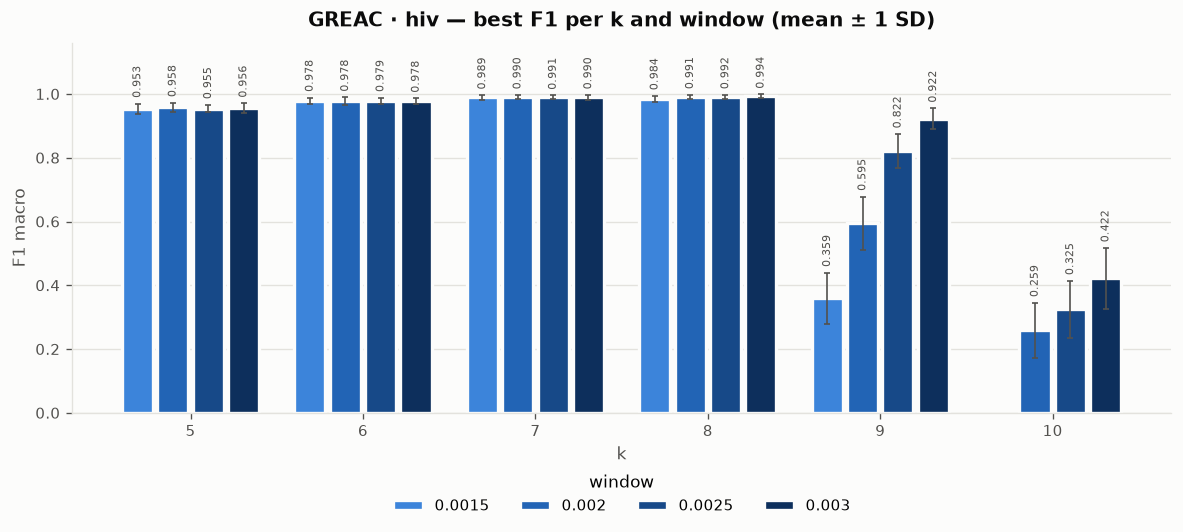

In [44]:
best_t = (ranking.sort_values("f1_score_mean", ascending=False)
          .drop_duplicates(subset=["window", "kmer"]))
colors = window_colors(WINDOWS)

x = np.arange(len(KS))
width = 0.82 / len(WINDOWS)
fig, ax = plt.subplots(figsize=(max(7.0, 0.34 * len(KS) * len(WINDOWS) + 1.8), 4.6))

for i, w in enumerate(WINDOWS):
    sub = best_t[best_t.window == w].set_index("kmer").reindex(KS)
    off = (i - (len(WINDOWS) - 1) / 2) * width
    ax.bar(x + off, sub.f1_score_mean.to_numpy(), width * 0.88, color=colors[w], label=f"{w}",
           edgecolor=SURFACE, linewidth=2,
           yerr=sub.f1_score_std.fillna(0).to_numpy(),
           error_kw=dict(ecolor=INK_2, elinewidth=1, capsize=2))
    # label above the top of the error bar, otherwise the text sits on the whisker
    top = sub.f1_score_mean + sub.f1_score_std.fillna(0)
    for xi, v, t in zip(x + off, sub.f1_score_mean, top):
        if not np.isnan(v):
            ax.annotate(f"{v:.3f}", (xi, t), xytext=(0, 5), textcoords="offset points",
                        ha="center", rotation=90, fontsize=6.5, color=INK_2)

ax.set_xticks(x, KS)
ax.set_ylim(0, 1.16)
ax.set_xlabel("k")
ax.set_ylabel("F1 macro")
ax.grid(axis="x", visible=False)
ax.set_title(f"{TITLE} — best F1 per k and window (mean ± 1 SD)")
ax.legend(title="window", loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncols=len(WINDOWS))
fig.tight_layout()
savefig(fig, "best_f1_per_k.png")
plt.show()

## 3. F1 × k curve per window

The sweep result for the paper: one line per window, each point being the best threshold for that window and k
(only combinations eligible by coverage), with a ±1 standard deviation band across repetitions. Same data as
the bars of section 2, read as a curve: where F1 peaks in k, how wide the plateau is, and whether the window
moves it. Saved as PNG and PDF.

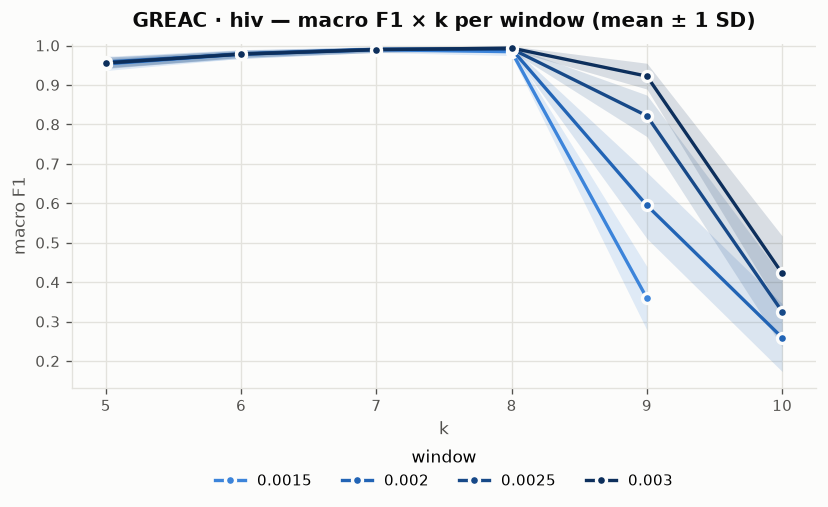

window,0.0015,0.0020,0.0025,0.0030
k,,,,
5,0.65,0.70,0.80,0.70
6,0.70,0.70,0.80,0.80
7,0.65,0.65,0.65,0.75
8,0.50,0.55,0.60,0.65
9,0.50,0.50,0.50,0.50
10,NaN,0.50,0.50,0.50


In [45]:
with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(4.4, 3.4))
    for w in WINDOWS:
        sub = best_t[best_t.window == w].sort_values("kmer")
        mean_band(ax, sub.kmer, sub.f1_score_mean, sub.f1_score_std, colors[w], label=f"{w * 100:g}%")   # janela em %, como no artigo

    ax.set_xticks(KS)
    ax.set_xlabel("k-mer size (k)")
    ax.set_ylabel("F1-score")
    ax.set_ylim(top=1.005)
    # sem título: a figura vai para o artigo, onde o caption identifica o organismo
    ax.legend(title="window size", loc="upper center", bbox_to_anchor=(0.5, -0.28), ncols=2 if len(WINDOWS) > 3 else len(WINDOWS),
              columnspacing=1.0, handlelength=1.5)
    fig.tight_layout()
    lo, hi = ax.get_ylim()   # a margem acima de 1 não vira marcação (F1 ≤ 1)
    ax.set_yticks([t for t in ax.get_yticks() if lo <= t <= 1])
    savefig(fig, "f1_vs_k_per_window.png")
    plt.show()

# the threshold behind each point, so the curve can be traced back to the grid
best_t.pivot(index="kmer", columns="window", values="threshold").rename_axis(index="k", columns="window")

## 4. Threshold × window heatmap, one panel per k

Color = mean F1 on a single-hue scale shared across panels. The scale starts at the median of the
combinations: everything below it gets the lightest tone (the arrow on the color bar), so color separates the
good combinations instead of spending the scale on those that collapse. Each cell shows its value, so color is
never the only channel. Hatched cell = combination not run; grey text = left out of the ranking by coverage.

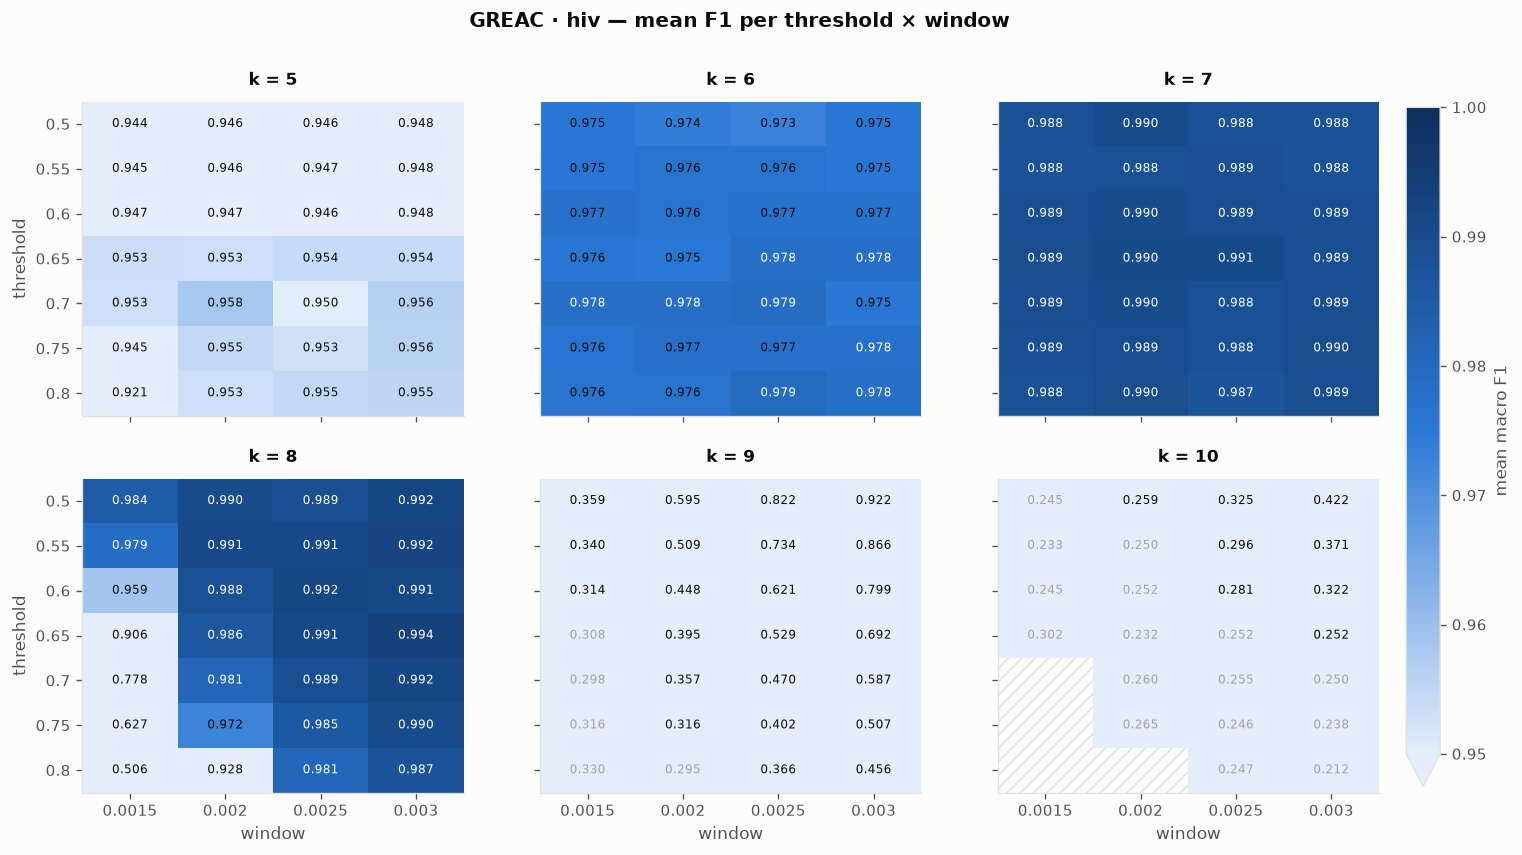

In [46]:
# Scale from the median (in 0.05 steps): with the collapse at high k reaching
# ~0.2, a 0–1 scale (or even one from the quartile) paints the whole
# 0.94–0.99 band in the same tone
vmin = min(np.floor(agg.f1_score_mean.median() * 20) / 20, 0.95)
cmap = SEQ.copy()
cmap.set_under(SEQ(0.0))
ncols = min(3, len(KS))
nrows = int(np.ceil(len(KS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.0 * len(WINDOWS) * ncols + 2.6, 0.42 * len(THRESHOLDS) * nrows + 1.6),
                         squeeze=False, sharex=True, sharey=True)

for ax, k in zip(axes.flat, KS):
    sub = agg[agg.kmer == k]
    mean_m = sub.pivot(index="threshold", columns="window", values="f1_score_mean").reindex(index=THRESHOLDS, columns=WINDOWS)
    elig_m = sub.pivot(index="threshold", columns="window", values="eligible").reindex(index=THRESHOLDS, columns=WINDOWS)
    im = ax.imshow(mean_m.values, cmap=cmap, vmin=vmin, vmax=1, aspect="auto")
    ax.grid(False)
    for i in range(mean_m.shape[0]):
        for j in range(mean_m.shape[1]):
            v = mean_m.values[i, j]
            if np.isnan(v):
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch="///",
                                           edgecolor=GRID, linewidth=0))
                continue
            dark = (v - vmin) / (1 - vmin) > 0.55
            color = MUTED if not elig_m.values[i, j] else ("#ffffff" if dark else INK)
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color=color)
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xticks(range(len(WINDOWS)), WINDOWS, rotation=0)
    ax.set_yticks(range(len(THRESHOLDS)), THRESHOLDS)

for ax in axes.flat[len(KS):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("threshold")
for ax in axes[-1]:
    ax.set_xlabel("window")

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, extend="min", label="mean macro F1")
fig.suptitle(f"{TITLE} — mean F1 per threshold × window",
             fontsize=12, fontweight="600", color=INK)
savefig(fig, "heatmap_threshold_window.png")
plt.show()

## 5. Coverage × F1

Each point is a combination (means over the repetitions). Points left of the line are out of the ranking:
any high F1 there holds for a fraction of the test set, not for the test set.

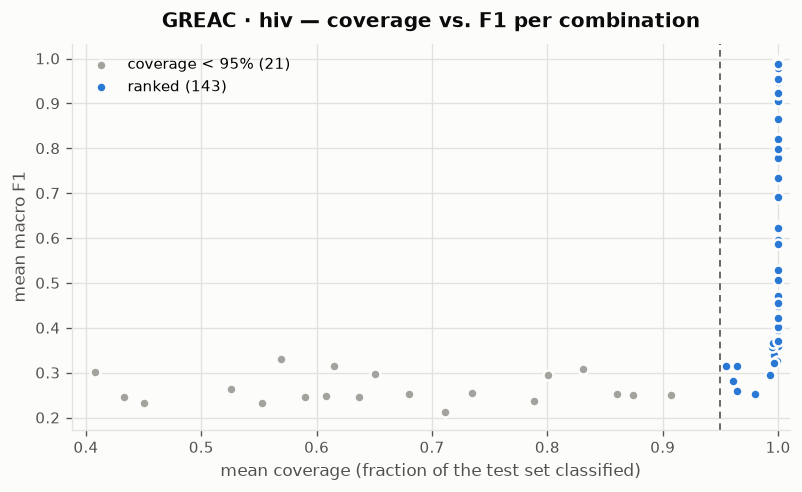

In [47]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
out = agg[~agg.eligible]
ok = agg[agg.eligible]
ax.scatter(out.coverage_mean, out.f1_score_mean, s=36, color=MUTED, edgecolor=SURFACE,
           linewidth=1.5, label=f"coverage < {MIN_COVERAGE:.0%} ({len(out)})")
ax.scatter(ok.coverage_mean, ok.f1_score_mean, s=36, color=ACCENT, edgecolor=SURFACE,
           linewidth=1.5, label=f"ranked ({len(ok)})")
ax.axvline(MIN_COVERAGE, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
ax.set_xlabel("mean coverage (fraction of the test set classified)")
ax.set_ylabel("mean macro F1")
ax.set_xlim(min(agg.coverage_mean.min() - 0.02, MIN_COVERAGE - 0.05), 1.01)
ax.set_title(f"{TITLE} — coverage vs. F1 per combination")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "coverage_vs_f1.png")
plt.show()

## 6. Runtime per k

Mean over all combinations and repetitions of each k. Training = `extractFeaturesTemplate` (extraction)
+ `getKmersDistributionPerClass` (fit); classification = `greacClassification` over the whole test set.
The first combination of each Julia run carries the compilation time, which is why the deviation of the
extraction across repetitions tends to be large.

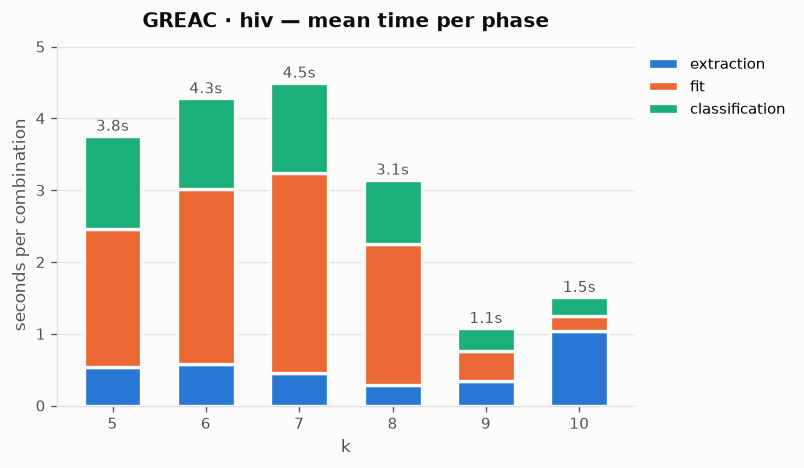

,extract_time,fit_time,classify_time,train
kmer,,,,
5,0.5394,1.9272,1.2931,2.4665
6,0.5773,2.4338,1.2698,3.0111
7,0.4516,2.7861,1.2617,3.2377
8,0.2935,1.9647,0.8910,2.2582
9,0.3476,0.4191,0.3157,0.7667
10,1.0430,0.2117,0.2596,1.2547


In [48]:
PHASES = [("extract_time", "extraction"), ("fit_time", "fit"), ("classify_time", "classification")]
timing = raw.groupby("kmer")[[p for p, _ in PHASES]].mean().reindex(KS)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
bottom = np.zeros(len(KS))

for (col, name), color in zip(PHASES, SERIES):
    bars = ax.bar(KS, timing[col], bottom=bottom, width=0.62, color=color, label=name,
                  edgecolor=SURFACE, linewidth=2)
    bottom += timing[col].to_numpy()
    
for x, total in zip(KS, bottom):
    ax.annotate(f"{total:.1f}s", (x, total), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

ax.set_xticks(KS)
ax.set_xlabel("k")
ax.set_ylabel("seconds per combination")
ax.grid(axis="x", visible=False)
ax.set_title(f"{TITLE} — mean time per phase")
ax.set_ylim(0, bottom.max() * 1.12)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()
savefig(fig, "time_per_phase.png")
plt.show()

rounded(timing.assign(train=timing.extract_time + timing.fit_time))

## 7. Per-repetition distribution of the best combinations

One point per repetition. Overlapping boxes are combinations the sweep cannot separate.

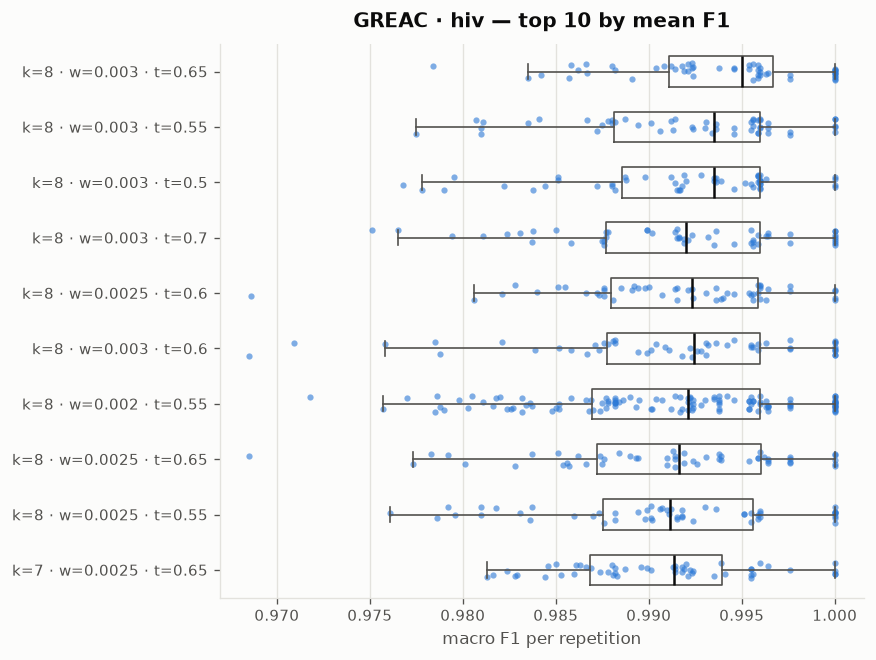

In [49]:
top = ranking.head(TOP_N)
labels, values = [], []
for _, r in top.iterrows():
    sel = raw[(raw.window == r.window) & (raw.threshold == r.threshold) & (raw.kmer == r.kmer)]
    labels.append(f"k={int(r.kmer)} · w={r.window} · t={r.threshold}")
    values.append(sel.f1_score.to_numpy())

fig, ax = plt.subplots(figsize=(7.4, 0.42 * len(top) + 1.4))
pos = np.arange(len(top))[::-1]
ax.boxplot(values, positions=pos, orientation="horizontal", widths=0.55, showfliers=False,
           medianprops=dict(color=INK, linewidth=1.5), boxprops=dict(color=INK_2),
           whiskerprops=dict(color=INK_2), capprops=dict(color=INK_2))
rng = np.random.default_rng(0)
for p, v in zip(pos, values):
    ax.scatter(v, p + rng.uniform(-0.15, 0.15, len(v)), s=14, color=ACCENT, alpha=0.6, linewidth=0)
ax.set_yticks(pos, labels)
ax.set_xlabel("macro F1 per repetition")
ax.grid(axis="y", visible=False)
ax.set_title(f"{TITLE} — top {len(top)} by mean F1")
fig.tight_layout()
savefig(fig, "top_distribution.png")
plt.show()

## 8. ROC and AUC (benchmark of the chosen configuration)

The sweep CSVs keep only F1/precision/recall, so this section reads the **benchmark** of the chosen
configuration, `GREAC/output-benchmark-<organism>/` (written by `scripts/local/batch_benchmark.sh`, one
independent train/test split per repetition). Every class is evaluated one-vs-rest. Two sources, which answer
different questions:

- **ROC curves and AUC — from the membership scores** (`classifications_<organism>.csv`). For each test sequence
  GREAC computes a Gaussian membership to every class and predicts the largest one. Sweeping a threshold over
  the membership of class *c* gives the ROC of *c* vs. the rest, and its area is the **threshold-independent AUC**
  the reviewer asks for. Reported per class and macro-averaged, as mean ± SD over repetitions. The file is only
  written when the benchmark runs with `MEMBERSHIPS=1`:

  ```bash
  MEMBERSHIPS=1 REPS=30 scripts/local/batch_benchmark.sh <organism> <window> <k> <threshold>
  ```

- **Operating points — from the confusion matrices** (`benchmark_results_<organism>.csv`). A confusion matrix is
  *one* point of the ROC: TPR = TP / (TP + FN) and FPR = FP / (FP + TN) at GREAC's decision rule (argmax of
  the memberships). The area under the two-segment curve through that single point is (TPR + 1 − FPR) / 2,
  i.e. the **balanced accuracy** — it depends on the decision rule, so it is *not* the threshold-independent
  AUC and should not be reported as such. It is shown as a point on each ROC panel: it marks where GREAC
  actually operates on the curve.

Class imbalance: ROC and AUC are computed from rates within each class (TPR over the positives, FPR over the
negatives), so they do not depend on how many sequences each class has in the test set.

In [50]:
BENCH_DIR = os.path.join(SWEEP_ROOT, f"output-benchmark-{ORGANISM}")
RESULTS_CSV = os.path.join(BENCH_DIR, f"benchmark_results_{ORGANISM}.csv")
MEMB_CSV = os.path.join(BENCH_DIR, f"classifications_{ORGANISM}.csv")


def roc_curve(y, score):
    """ROC of a binary problem: (fpr, tpr, auc). Tied scores become one step, as in sklearn."""
    order = np.argsort(-score, kind="mergesort")
    y, score = y[order], score[order]
    last = np.r_[np.flatnonzero(np.diff(score)), len(score) - 1]   # last index of each distinct score
    tps = np.cumsum(y)[last]
    fps = last + 1 - tps
    tpr = np.r_[0, tps / tps[-1]]
    fpr = np.r_[0, fps / fps[-1]]
    return fpr, tpr, np.trapezoid(tpr, fpr)


# self-check: perfect, inverted and fully tied scores (AUC 1, 0 and 0.5)
_y = np.array([1, 1, 0, 0])
assert roc_curve(_y, np.array([0.9, 0.8, 0.2, 0.1]))[2] == 1
assert roc_curve(_y, np.array([0.1, 0.2, 0.8, 0.9]))[2] == 0
assert roc_curve(_y, np.full(4, 0.5))[2] == 0.5
# mixed case against the Mann–Whitney formula (P(score_pos > score_neg) + ½ P(tie))
_s = np.array([0.9, 0.4, 0.4, 0.1]); _y2 = np.array([1, 0, 1, 0])
_p, _n = _s[_y2 == 1], _s[_y2 == 0]
assert np.isclose(roc_curve(_y2, _s)[2],
                  ((_p[:, None] > _n).mean() + 0.5 * (_p[:, None] == _n).mean()))


def parse_cm(text):
    """'[a b; c d]' as the benchmark writes it (rows = true class, columns = predicted)."""
    return np.array([[float(v) for v in row.split()] for row in text.strip(" []").split(";")])


# --- operating points from the confusion matrices -------------------------------
points = pd.DataFrame()
CLASSES = []
if os.path.exists(RESULTS_CSV):
    bench = pd.read_csv(RESULTS_CSV)
    cols = list(bench.columns)
    CLASSES = cols[cols.index("final_len") + 1:cols.index("macro_f1")]   # same order as the matrix
    rows = []
    for _, r in bench.iterrows():
        cm = parse_cm(r.cm)
        for i, c in enumerate(CLASSES):
            tp = cm[i, i]
            fn = cm[i].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            rows.append({"rep": r.rep, "class": c, "tpr": tp / (tp + fn), "fpr": fp / (fp + tn)})
    points = pd.DataFrame(rows)
    points["point_auc"] = (points.tpr + 1 - points.fpr) / 2          # = balanced accuracy
    print(f"benchmark: {bench.rep.nunique()} repetitions, window={bench.wndwPercent.iloc[0]}, "
          f"k={bench.k.iloc[0]}, classes={CLASSES}")
    print(f"sweep choice (section 1): window={choice.window}, threshold={choice.threshold}, k={int(choice.kmer)}")
else:
    print(f"no {RESULTS_CSV}: run scripts/local/batch_benchmark.sh for {ORGANISM} first")

# --- ROC curves from the membership scores --------------------------------------
FPR_GRID = np.linspace(0, 1, 201)
auc = pd.DataFrame()
curves = {}
if os.path.exists(MEMB_CSV):
    memb = pd.read_csv(MEMB_CSV)
    if "rep" not in memb.columns:
        # files written before the fix had no rep column and could put each membership under
        # the wrong class (Dict order): any ROC built from them would be wrong
        print(f"{MEMB_CSV} predates the membership-column fix; regenerate it with MEMBERSHIPS=1")
    else:
        CLASSES = [c for c in memb.columns if c not in ("rep", "id", "predicted_label", "true_label")]
        memb = memb.dropna(subset=CLASSES)
        rows, grids = [], {c: [] for c in CLASSES}
        for rep, g in memb.groupby("rep"):
            for c in CLASSES:
                y = (g.true_label == c).to_numpy(int)
                if y.min() == y.max():          # class absent (or alone) in this split
                    continue
                fpr, tpr, a = roc_curve(y, g[c].to_numpy())
                rows.append({"rep": rep, "class": c, "auc": a})
                grids[c].append(np.r_[0, np.interp(FPR_GRID[1:], fpr, tpr)])   # curve starts at the origin
        auc = pd.DataFrame(rows)
        curves = {c: (np.mean(v, axis=0), np.std(v, axis=0)) for c, v in grids.items() if v}
        print(f"memberships: {memb.rep.nunique()} repetitions, {len(memb)} scored sequences")
else:
    print(f"no {MEMB_CSV}: ROC curves need the benchmark run with MEMBERSHIPS=1 "
          f"(only the confusion-matrix operating points are shown)")

benchmark: 100 repetitions, window=0.002, k=8, classes=['HIV1_F.fasta', 'HIV1_D.fasta', 'HIV1_C.fasta', 'HIV1_A.fasta', 'HIV1_B.fasta', 'HIV1_G.fasta']
sweep choice (section 1): window=0.0025, threshold=0.7, k=8
memberships: 100 repetitions, 29500 scored sequences


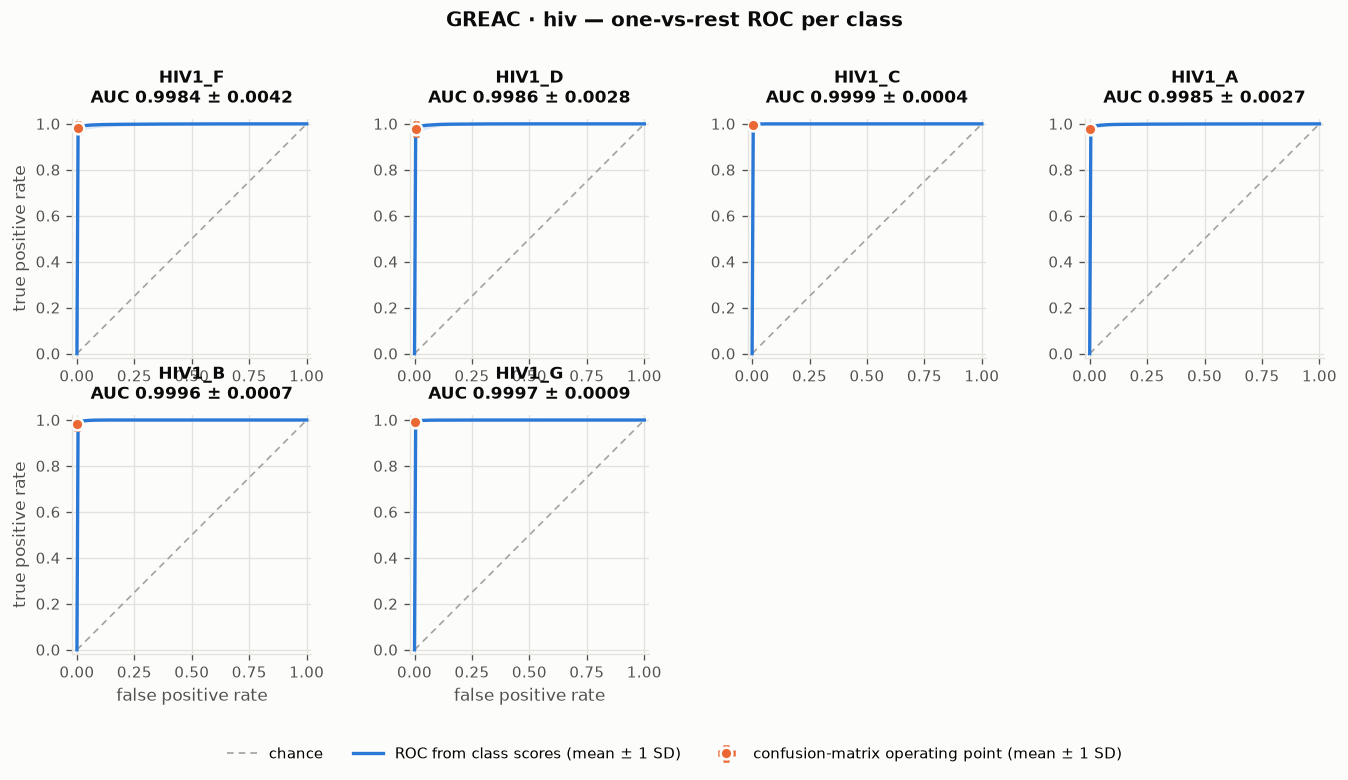

In [51]:
if points.empty and auc.empty:
    print("nothing to plot for", ORGANISM)
else:
    with plt.rc_context(PAPER_RC):
        show = CLASSES
        ncols = min(4, len(show))
        nrows = int(np.ceil(len(show) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows + 0.6),
                                 squeeze=False, sharex=True, sharey=True)
        for ax, c in zip(axes.flat, show):
            ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle=(0, (4, 3)), label="chance")
            title = c.removesuffix(".fasta")
            if c in curves:
                m, s = curves[c]
                ax.fill_between(FPR_GRID, np.clip(m - s, 0, 1), np.clip(m + s, 0, 1),
                                color=ACCENT, alpha=0.15, linewidth=0)
                ax.plot(FPR_GRID, m, color=ACCENT, label="ROC curve (mean ± 1 SD)")
                a = auc[auc["class"] == c].auc
                # no canto inferior direito (vazio numa ROC): no título, a linha é mais larga que o painel
                ax.text(0.97, 0.04, f"AUC {a.mean():.{DECIMALS}f}\n± {a.std():.{DECIMALS}f}",
                        transform=ax.transAxes, ha="right", va="bottom", color=INK)
            if not points.empty:
                q = points[points["class"] == c]
                ax.errorbar(q.fpr.mean(), q.tpr.mean(), xerr=q.fpr.std(), yerr=q.tpr.std(),
                            fmt="o", color=SERIES[1], markersize=7, markeredgecolor=SURFACE,
                            markeredgewidth=1.5, elinewidth=1, capsize=2, zorder=3,
                            label="argmax operating point (mean ± 1 SD)")
            ax.set_title(title)
            ax.set_xlim(-0.02, 1.02)
            ax.set_ylim(-0.02, 1.02)
            ax.set_aspect("equal")
            ax.set_xticks([0, 0.5, 1])
            ax.set_yticks([0, 0.5, 1])
            ax.tick_params(labelbottom=True, labelleft=True)
        for ax in axes.flat[len(show):]:
            ax.set_visible(False)
        for ax in axes[:, 0]:
            ax.set_ylabel("true positive rate")
        for ax in axes[-1]:
            ax.set_xlabel("false positive rate")
        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncols=len(labels), bbox_to_anchor=(0.5, 0))
        # sem título: a figura vai para o artigo, onde o caption identifica o organismo
        fig.tight_layout(rect=(0, 0.5 / fig.get_figheight(), 1, 1))   # ~0.5 in for the legend
        savefig(fig, "roc_per_class.png")
        plt.show()

In [52]:
# Per class: threshold-independent AUC (scores) next to the operating point (confusion matrix).
# The "macro" row averages the classes within each repetition first, then over repetitions.
def mean_sd(frame, col):
    per_rep = frame.groupby("rep")[col].mean()
    return frame.groupby("class")[col].agg(["mean", "std"]), (per_rep.mean(), per_rep.std())

table = pd.DataFrame(index=pd.Index(CLASSES + ["macro"], name="class")) if CLASSES else pd.DataFrame()
if not auc.empty:
    by, macro = mean_sd(auc, "auc")
    table["AUC_mean"], table["AUC_sd"] = by["mean"], by["std"]
    table.loc["macro", ["AUC_mean", "AUC_sd"]] = macro
if not points.empty:
    for col, name in [("tpr", "TPR"), ("fpr", "FPR"), ("point_auc", "balanced_acc")]:
        by, macro = mean_sd(points, col)
        table[f"{name}_mean"], table[f"{name}_sd"] = by["mean"], by["std"]
        table.loc["macro", [f"{name}_mean", f"{name}_sd"]] = macro
if not table.empty:
    table.index = table.index.str.removesuffix(".fasta")
    table.to_csv(os.path.join(FIG_DIR, "roc_auc.csv"))
table.round(DECIMALS)

,AUC_mean,AUC_sd,TPR_mean,TPR_sd,FPR_mean,FPR_sd,balanced_acc_mean,balanced_acc_sd
class,,,,,,,,
HIV1_F,0.9984,0.0042,0.9838,0.0227,0.0056,0.0053,0.9891,0.0113
HIV1_D,0.9986,0.0028,0.9792,0.0303,0.0047,0.0051,0.9873,0.0154
HIV1_C,0.9999,0.0004,0.9946,0.0110,0.0020,0.0033,0.9963,0.0057
HIV1_A,0.9985,0.0027,0.9764,0.0216,0.0025,0.0039,0.9869,0.0109
HIV1_B,0.9996,0.0007,0.9806,0.0227,0.0020,0.0032,0.9893,0.0114
HIV1_G,0.9997,0.0009,0.9894,0.0199,0.0019,0.0034,0.9938,0.0099
macro,0.9991,0.0009,0.9840,0.0089,0.0031,0.0017,0.9904,0.0052


## 9. Summary table

In [53]:
agg.sort_values("f1_score_mean", ascending=False).round(6) \
   .to_csv(os.path.join(FIG_DIR, "summary.csv"), index=False)
print("figures and table in", FIG_DIR)
agg.sort_values("f1_score_mean", ascending=False)[SHOW + ["eligible"]].pipe(rounded)

figures and table in figs/greac/hiv


,window,threshold,kmer,n,f1_score_mean,f1_score_std,precision_mean,recall_mean,coverage_mean,kmerset_mean,final_len_mean,windows_mean,train_time_mean,classify_time_mean,eligible
143,0.0030,0.65,8,52,0.9936,0.0052,0.9925,0.9950,1.0000,775.5000,8630.9423,4.3462,3.0224,1.4393,True
131,0.0030,0.55,8,52,0.9921,0.0057,0.9908,0.9938,1.0000,775.5000,8901.4808,2.6923,3.1055,1.4284,True
125,0.0030,0.50,8,52,0.9918,0.0058,0.9900,0.9938,1.0000,775.5000,8972.9808,2.1346,3.0160,1.4600,True
149,0.0030,0.70,8,52,0.9917,0.0064,0.9901,0.9934,1.0000,775.5000,8435.2115,5.3846,3.2689,1.4581,True
95,0.0025,0.60,8,52,0.9916,0.0058,0.9901,0.9934,1.0000,775.5000,8528.3077,6.3846,2.9844,1.3208,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.0015,0.50,10,102,0.2452,0.0667,0.2997,0.2841,0.5897,138.3824,57.7647,2.8039,1.1263,0.1472,False
157,0.0030,0.75,10,45,0.2377,0.0732,0.3075,0.2829,0.7887,138.5778,94.4444,2.0667,1.3080,0.2510,False
11,0.0015,0.55,10,53,0.2333,0.0830,0.2789,0.2755,0.4505,143.3019,28.1509,1.5283,1.0887,0.1132,False
62,0.0020,0.65,10,56,0.2324,0.0750,0.2807,0.2739,0.5530,141.0714,34.5714,1.3571,1.0752,0.1063,False
